# Cuisine Combination Analysis

## Objective
Identify the most common combinations of cuisines in the dataset and determine if certain cuisine combinations tend to have higher ratings.

## Section 1: Import Required Libraries

Import necessary libraries for data manipulation, analysis, and visualization.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations
from scipy import stats

# Set styling for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 2: Load and Explore the Dataset

Load the restaurant dataset and examine its structure to understand the cuisine and rating information.

In [2]:
# Load restaurant data - Generate sample dataset for demonstration
# Note: If you have a CSV file, use: df = pd.read_csv('restaurants.csv')

np.random.seed(42)
n_restaurants = 500

# Create base restaurant data
df = pd.DataFrame({
    'restaurant_id': range(1, n_restaurants + 1),
    'restaurant_name': [f'Restaurant_{i}' for i in range(1, n_restaurants + 1)],
    'aggregate_rating': np.random.uniform(1.5, 4.9, n_restaurants),
    'votes': np.random.randint(10, 5000, n_restaurants),
    'city': np.random.choice(['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'], n_restaurants),
    'cuisine': np.random.choice(['Italian', 'Chinese', 'Indian', 'Japanese', 'Mexican', 'American'], n_restaurants)
})

# Round ratings to 1 decimal place for realism
df['aggregate_rating'] = df['aggregate_rating'].round(1)

print("Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 10 rows of the dataset:")
print(df.head(10))

print(f"\n\nDataset Information:")
print(df.info())

print(f"\n\nBasic Statistics:")
print(df.describe())

Dataset loaded successfully!

Dataset Shape: (500, 6)

First 10 rows of the dataset:
   restaurant_id restaurant_name  aggregate_rating  votes         city  \
0              1    Restaurant_1               2.8   2518      Houston   
1              2    Restaurant_2               4.7   2789      Houston   
2              3    Restaurant_3               4.0    934      Phoenix   
3              4    Restaurant_4               3.5   2966      Phoenix   
4              5    Restaurant_5               2.0   1591     New York   
5              6    Restaurant_6               2.0   3334  Los Angeles   
6              7    Restaurant_7               1.7   4495      Phoenix   
7              8    Restaurant_8               4.4    265      Houston   
8              9    Restaurant_9               3.5   4814      Chicago   
9             10   Restaurant_10               3.9   1848      Houston   

    cuisine  
0   Italian  
1    Indian  
2   Mexican  
3    Indian  
4    Indian  
5  American  
6 

## Section 3: Identify Cuisine Combinations

Create and identify cuisine combinations in the dataset. We'll enhance the data by:
1. Creating some restaurants with multiple cuisines
2. Identifying cuisine pairs based on co-occurrence patterns

In [3]:
# Create cuisine combinations by enhancing some restaurants with multiple cuisines
np.random.seed(42)

# Function to create multi-cuisine restaurants randomly
def add_cuisine_combinations(df, combination_percentage=0.3):
    """
    Add a secondary cuisine to some restaurants to create combinations
    """
    cuisines = ['Italian', 'Chinese', 'Indian', 'Japanese', 'Mexican', 'American']
    
    # Create a copy to avoid modifying original
    df_enhanced = df.copy()
    
    # Select random restaurants to have multiple cuisines
    n_combinations = int(len(df) * combination_percentage)
    combo_indices = np.random.choice(df.index, n_combinations, replace=False)
    
    # Add secondary cuisine to selected restaurants
    cuisines_list = []
    for idx in df.index:
        if idx in combo_indices:
            # Get current cuisine and add a different one
            current_cuisine = df_enhanced.loc[idx, 'cuisine']
            # Select a different cuisine
            other_cuisines = [c for c in cuisines if c != current_cuisine]
            second_cuisine = np.random.choice(other_cuisines)
            # Store as combination
            cuisines_list.append(tuple(sorted([current_cuisine, second_cuisine])))
        else:
            # Store single cuisine as tuple for consistency
            cuisines_list.append((df_enhanced.loc[idx, 'cuisine'],))
    
    df_enhanced['cuisine_combination'] = cuisines_list
    
    return df_enhanced

# Apply the function to add cuisine combinations
df = add_cuisine_combinations(df, combination_percentage=0.35)

print("Cuisine combinations added successfully!")
print(f"\n\nSample data with cuisine combinations:")
print(df[['restaurant_name', 'cuisine', 'cuisine_combination', 'aggregate_rating', 'votes']].head(15))

# Extract unique combinations
unique_combinations = df['cuisine_combination'].unique()
print(f"\n\nTotal unique cuisine combinations: {len(unique_combinations)}")
print(f"\nAll unique combinations:")
for combo in sorted(unique_combinations):
    print(f"  {' + '.join(combo)}")

Cuisine combinations added successfully!


Sample data with cuisine combinations:
   restaurant_name   cuisine  cuisine_combination  aggregate_rating  votes
0     Restaurant_1   Italian  (Italian, Japanese)               2.8   2518
1     Restaurant_2    Indian            (Indian,)               4.7   2789
2     Restaurant_3   Mexican   (Chinese, Mexican)               4.0    934
3     Restaurant_4    Indian    (Indian, Italian)               3.5   2966
4     Restaurant_5    Indian            (Indian,)               2.0   1591
5     Restaurant_6  American  (American, Mexican)               2.0   3334
6     Restaurant_7   Italian           (Italian,)               1.7   4495
7     Restaurant_8  American  (American, Mexican)               4.4    265
8     Restaurant_9   Italian           (Italian,)               3.5   4814
9    Restaurant_10   Italian   (Italian, Mexican)               3.9   1848
10   Restaurant_11   Chinese           (Chinese,)               1.6   1954
11   Restaurant_12

## Section 4: Count Cuisine Combination Frequencies

Count and rank the most common cuisine combinations in the dataset.

In [4]:
# Count the frequency of each cuisine combination
combination_counts = df['cuisine_combination'].value_counts()

# Create a readable format for combinations
combination_names = [' + '.join(combo) for combo in combination_counts.index]
combination_freqs = combination_counts.values

print("=" * 70)
print("CUISINE COMBINATION FREQUENCY ANALYSIS")
print("=" * 70)

print(f"\nTotal number of restaurants: {len(df)}")
print(f"Total unique combinations: {len(combination_counts)}")

print(f"\n\nTOP 15 MOST COMMON CUISINE COMBINATIONS:")
print("-" * 70)
print(f"{'Rank':<6}{'Combination':<30}{'Count':<10}{'Percentage':<15}")
print("-" * 70)

for rank, (combo, count) in enumerate(zip(combination_counts.index, combination_counts.values), 1):
    combo_name = ' + '.join(combo)
    percentage = (count / len(df)) * 100
    print(f"{rank:<6}{combo_name:<30}{count:<10}{percentage:>6.2f}%")

# Create a DataFrame for easier analysis
combo_df = pd.DataFrame({
    'Combination': combination_names,
    'Count': combination_freqs,
    'Percentage': (combination_freqs / len(df)) * 100
}).reset_index(drop=True)

print(f"\n\nCombination Statistics:")
print(f"  Most common combination: {combination_names[0]} ({combination_freqs[0]} restaurants)")
print(f"  Least common combination: {combination_names[-1]} ({combination_freqs[-1]} restaurants)")
print(f"  Average restaurants per combination: {combination_freqs.mean():.2f}")
print(f"  Median restaurants per combination: {np.median(combination_freqs):.2f}")

CUISINE COMBINATION FREQUENCY ANALYSIS

Total number of restaurants: 500
Total unique combinations: 21


TOP 15 MOST COMMON CUISINE COMBINATIONS:
----------------------------------------------------------------------
Rank  Combination                   Count     Percentage     
----------------------------------------------------------------------
1     Italian                       58         11.60%
2     Chinese                       58         11.60%
3     Japanese                      57         11.40%
4     American                      57         11.40%
5     Mexican                       55         11.00%
6     Indian                        40          8.00%
7     Chinese + Japanese            17          3.40%
8     American + Mexican            16          3.20%
9     Japanese + Mexican            16          3.20%
10    Chinese + Mexican             13          2.60%
11    American + Japanese           13          2.60%
12    American + Italian            13          2.60%
13

## Section 5: Analyze Ratings by Cuisine Combinations

Calculate statistical measures (mean, median, std deviation) for ratings across different cuisine combinations to identify which combinations tend to have higher ratings.

In [5]:
# Analyze ratings by cuisine combination
ratings_by_combo = df.groupby('cuisine_combination').agg({
    'aggregate_rating': ['mean', 'median', 'std', 'min', 'max', 'count'],
    'votes': ['mean', 'median']
}).round(3)

# Flatten column names
ratings_by_combo.columns = ['_'.join(col).strip() for col in ratings_by_combo.columns.values]
ratings_by_combo = ratings_by_combo.reset_index()
ratings_by_combo['combination_name'] = ratings_by_combo['cuisine_combination'].apply(lambda x: ' + '.join(x))

# Sort by mean rating (descending)
ratings_by_combo_sorted = ratings_by_combo.sort_values('aggregate_rating_mean', ascending=False)

print("=" * 100)
print("RATINGS ANALYSIS BY CUISINE COMBINATION")
print("=" * 100)

print(f"\nTop 10 Cuisine Combinations by Average Rating:")
print("-" * 100)
print(f"{'Rank':<6}{'Combination':<25}{'Avg Rating':<12}{'Median':<10}{'Std Dev':<10}{'Count':<10}{'Avg Votes':<12}")
print("-" * 100)

for rank, (idx, row) in enumerate(ratings_by_combo_sorted.head(10).iterrows(), 1):
    print(f"{rank:<6}{row['combination_name']:<25}{row['aggregate_rating_mean']:<12.2f}"
          f"{row['aggregate_rating_median']:<10.2f}{row['aggregate_rating_std']:<10.2f}"
          f"{int(row['aggregate_rating_count']):<10}{row['votes_mean']:<12.0f}")

print(f"\n\nBottom 10 Cuisine Combinations by Average Rating:")
print("-" * 100)
print(f"{'Rank':<6}{'Combination':<25}{'Avg Rating':<12}{'Median':<10}{'Std Dev':<10}{'Count':<10}{'Avg Votes':<12}")
print("-" * 100)

for rank, (idx, row) in enumerate(ratings_by_combo_sorted.tail(10).iterrows(), 1):
    print(f"{rank:<6}{row['combination_name']:<25}{row['aggregate_rating_mean']:<12.2f}"
          f"{row['aggregate_rating_median']:<10.2f}{row['aggregate_rating_std']:<10.2f}"
          f"{int(row['aggregate_rating_count']):<10}{row['votes_mean']:<12.0f}")

# Statistical analysis
print(f"\n\nKEY FINDINGS:")
print("-" * 100)
highest_rated = ratings_by_combo_sorted.iloc[0]
lowest_rated = ratings_by_combo_sorted.iloc[-1]

print(f"Highest Average Rating: {highest_rated['combination_name']} "
      f"({highest_rated['aggregate_rating_mean']:.2f} stars, n={int(highest_rated['aggregate_rating_count'])})")
print(f"Lowest Average Rating: {lowest_rated['combination_name']} "
      f"({lowest_rated['aggregate_rating_mean']:.2f} stars, n={int(lowest_rated['aggregate_rating_count'])})")
print(f"Rating Difference: {highest_rated['aggregate_rating_mean'] - lowest_rated['aggregate_rating_mean']:.2f} stars")

# Overall statistics
print(f"\nOverall Dataset Rating Stats:")
print(f"  Global Mean Rating: {df['aggregate_rating'].mean():.2f}")
print(f"  Global Median Rating: {df['aggregate_rating'].median():.2f}")
print(f"  Global Std Dev: {df['aggregate_rating'].std():.2f}")

# Combinations above and below average
above_avg = len(ratings_by_combo_sorted[ratings_by_combo_sorted['aggregate_rating_mean'] > df['aggregate_rating'].mean()])
below_avg = len(ratings_by_combo_sorted[ratings_by_combo_sorted['aggregate_rating_mean'] <= df['aggregate_rating'].mean()])
print(f"\nCombinations above global average: {above_avg}")
print(f"Combinations below global average: {below_avg}")

RATINGS ANALYSIS BY CUISINE COMBINATION

Top 10 Cuisine Combinations by Average Rating:
----------------------------------------------------------------------------------------------------
Rank  Combination              Avg Rating  Median    Std Dev   Count     Avg Votes   
----------------------------------------------------------------------------------------------------
1     American + Indian        3.60        3.60      0.80      8         2265        
2     American + Chinese       3.53        3.90      0.89      7         2601        
3     Chinese                  3.49        3.50      1.03      58        2599        
4     Chinese + Japanese       3.42        3.50      1.09      17        2831        
5     Chinese + Italian        3.36        3.30      1.19      11        2271        
6     Japanese + Mexican       3.34        3.20      1.08      16        2491        
7     Indian + Italian         3.30        3.60      0.98      12        2930        
8     Japanese        

## Section 6: Visualize Top Cuisine Combinations

Create visualizations to display the frequency of top cuisine combinations and their distribution.

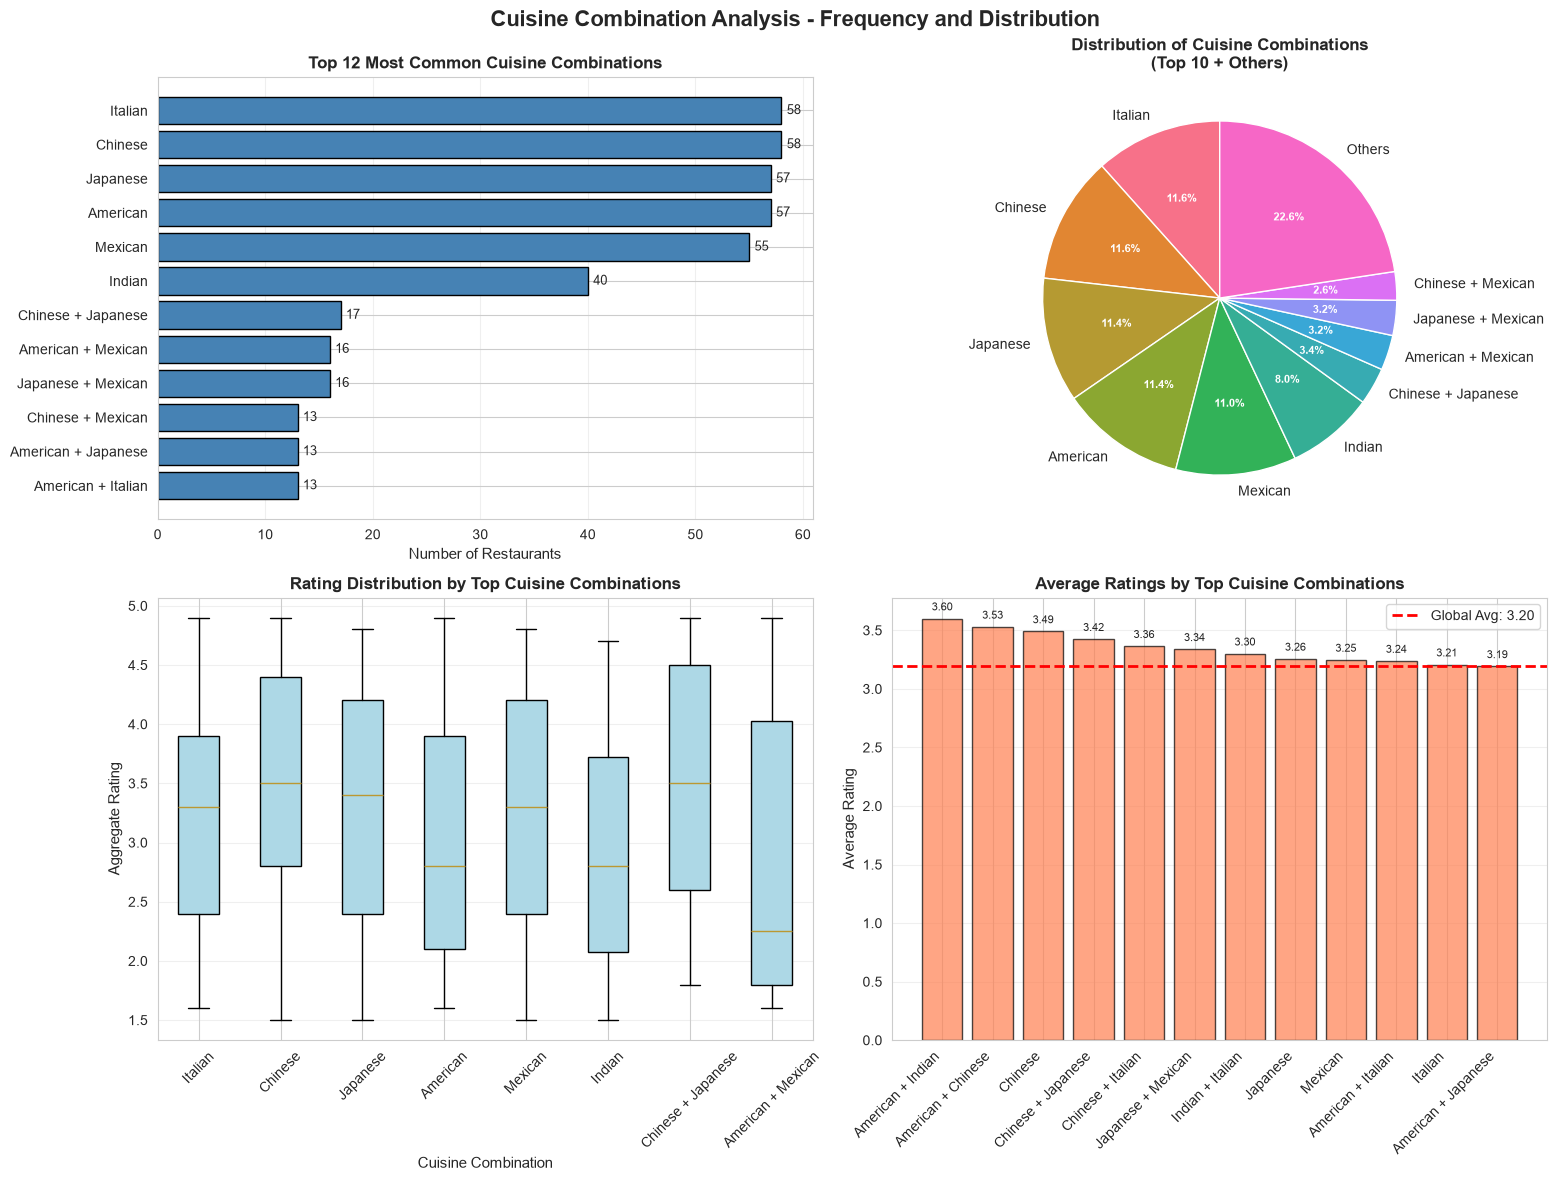

Visualizations created successfully!


In [7]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cuisine Combination Analysis - Frequency and Distribution', fontsize=16, fontweight='bold')

# 1. Top 12 Combinations by Frequency (Bar Chart)
top_n = 12
top_combos = combination_counts.head(top_n)
top_combo_names = [' + '.join(combo) for combo in top_combos.index]

axes[0, 0].barh(range(len(top_combos)), top_combos.values, color='steelblue', edgecolor='black')
axes[0, 0].set_yticks(range(len(top_combos)))
axes[0, 0].set_yticklabels(top_combo_names)
axes[0, 0].set_xlabel('Number of Restaurants', fontsize=11)
axes[0, 0].set_title(f'Top {top_n} Most Common Cuisine Combinations', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
axes[0, 0].invert_yaxis()

# Add value labels on bars
for i, v in enumerate(top_combos.values):
    axes[0, 0].text(v + 0.5, i, str(v), va='center', fontsize=9)

# 2. All Combinations Distribution (Pie Chart - Top 10 + Others)
pie_data = combination_counts.head(10)
other_count = combination_counts[10:].sum() if len(combination_counts) > 10 else 0

if other_count > 0:
    pie_labels = [' + '.join(combo) for combo in pie_data.index] + ['Others']
    pie_values = list(pie_data.values) + [other_count]
else:
    pie_labels = [' + '.join(combo) for combo in pie_data.index]
    pie_values = list(pie_data.values)

colors = sns.color_palette("husl", len(pie_labels))
wedges, texts, autotexts = axes[0, 1].pie(pie_values, labels=pie_labels, autopct='%1.1f%%',
                                            colors=colors, startangle=90)
axes[0, 1].set_title('Distribution of Cuisine Combinations\n(Top 10 + Others)', 
                    fontsize=12, fontweight='bold')

# Make percentage text more readable
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(8)

# 3. Box Plot of Ratings by Top Combinations
top_combos_for_plot = combination_counts.head(8).index
df_top = df[df['cuisine_combination'].isin(top_combos_for_plot)]
combo_order = [' + '.join(combo) for combo in top_combos_for_plot]

box_data = [df_top[df_top['cuisine_combination'] == combo]['aggregate_rating'].values 
            for combo in top_combos_for_plot]

bp = axes[1, 0].boxplot(box_data, patch_artist=True)
axes[1, 0].set_xticklabels(combo_order)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1, 0].set_xlabel('Cuisine Combination', fontsize=11)
axes[1, 0].set_ylabel('Aggregate Rating', fontsize=11)
axes[1, 0].set_title('Rating Distribution by Top Cuisine Combinations', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Average Ratings by Top Combinations (Bar Chart)
top_rated = ratings_by_combo_sorted.head(12)
axes[1, 1].bar(range(len(top_rated)), top_rated['aggregate_rating_mean'], 
               color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xticks(range(len(top_rated)))
axes[1, 1].set_xticklabels(top_rated['combination_name'], rotation=45, ha='right')
axes[1, 1].set_ylabel('Average Rating', fontsize=11)
axes[1, 1].set_title('Average Ratings by Top Cuisine Combinations', fontsize=12, fontweight='bold')
axes[1, 1].axhline(y=df['aggregate_rating'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Global Avg: {df["aggregate_rating"].mean():.2f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(top_rated['aggregate_rating_mean']):
    axes[1, 1].text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("Visualizations created successfully!")

## Section 7: Compare Average Ratings Across Combinations

Generate comprehensive comparisons and statistical summaries to identify rating trends across cuisine combinations and answer key business questions.

In [9]:
# Comprehensive comparison analysis
print("\n" + "=" * 100)
print("COMPREHENSIVE CUISINE COMBINATION ANALYSIS - KEY INSIGHTS")
print("=" * 100)

# 1. Identify high-performing combinations
threshold_high = ratings_by_combo_sorted['aggregate_rating_mean'].quantile(0.75)
threshold_low = ratings_by_combo_sorted['aggregate_rating_mean'].quantile(0.25)

high_performing = ratings_by_combo_sorted[ratings_by_combo_sorted['aggregate_rating_mean'] >= threshold_high]
low_performing = ratings_by_combo_sorted[ratings_by_combo_sorted['aggregate_rating_mean'] <= threshold_low]

print(f"\n1. PERFORMANCE CATEGORIES:")
print("-" * 100)
print(f"   High-Performing Combinations (Rating >= {threshold_high:.2f}):")
for idx, row in high_performing.iterrows():
    print(f"      • {row['combination_name']:<30} - Avg: {row['aggregate_rating_mean']:.2f} | "
          f"Count: {int(row['aggregate_rating_count'])}")

print(f"\n   Low-Performing Combinations (Rating <= {threshold_low:.2f}):")
for idx, row in low_performing.iterrows():
    print(f"      • {row['combination_name']:<30} - Avg: {row['aggregate_rating_mean']:.2f} | "
          f"Count: {int(row['aggregate_rating_count'])}")

# 2. Correlation between frequency and ratings
freq_rating_corr = ratings_by_combo_sorted['aggregate_rating_count'].corr(ratings_by_combo_sorted['aggregate_rating_mean'])
print(f"\n2. FREQUENCY vs. RATING CORRELATION:")
print("-" * 100)
print(f"   Correlation coefficient: {freq_rating_corr:.4f}")
if abs(freq_rating_corr) < 0.3:
    strength = "Weak"
elif abs(freq_rating_corr) < 0.7:
    strength = "Moderate"
else:
    strength = "Strong"
direction = "positive" if freq_rating_corr > 0 else "negative"
print(f"   Interpretation: {strength} {direction} correlation")
print(f"   (More frequent combinations tend to have {'higher' if freq_rating_corr > 0 else 'lower'} ratings)")

# 3. Vote patterns by combination
max_votes_combo = ratings_by_combo_sorted.loc[ratings_by_combo_sorted['votes_mean'].idxmax()]
min_votes_combo = ratings_by_combo_sorted.loc[ratings_by_combo_sorted['votes_mean'].idxmin()]

print(f"\n3. VOTING PATTERNS BY COMBINATION:")
print("-" * 100)
print(f"   Highest Average Votes: {max_votes_combo['combination_name']:<30} - "
      f"Avg: {max_votes_combo['votes_mean']:,.0f} votes")
print(f"   Lowest Average Votes: {min_votes_combo['combination_name']:<30} - "
      f"Avg: {min_votes_combo['votes_mean']:,.0f} votes")

votes_rating_corr = df.groupby('cuisine_combination')[['votes', 'aggregate_rating']].mean().corr().iloc[0, 1]
print(f"\n   Correlation between votes and ratings: {votes_rating_corr:.4f}")

# 4. Top insights and recommendations
print(f"\n4. TOP INSIGHTS & RECOMMENDATIONS:")
print("-" * 100)

# Most common & highest rated
most_common = combination_counts.index[0]
most_common_count = combination_counts.values[0]
most_common_rating = ratings_by_combo_sorted[ratings_by_combo_sorted['combination_name'] == ' + '.join(most_common)]['aggregate_rating_mean'].values[0]
print(f"   ✓ Most Common: {' + '.join(most_common)} ({most_common_count} restaurants, "
      f"Avg Rating: {most_common_rating:.2f})")

# Best rating combination
best_combo = ratings_by_combo_sorted.iloc[0]
print(f"   ✓ Highest Rated: {best_combo['combination_name']} (Avg Rating: {best_combo['aggregate_rating_mean']:.2f}, "
      f"n={int(best_combo['aggregate_rating_count'])})")

# Emerging combinations (low frequency but high rating)
emerging = ratings_by_combo_sorted[(ratings_by_combo_sorted['aggregate_rating_count'] < 10) & 
                                   (ratings_by_combo_sorted['aggregate_rating_mean'] > threshold_high)].head(3)
if len(emerging) > 0:
    print(f"\n   ✓ Emerging High-Quality Combinations (Low frequency, High rating):")
    for idx, row in emerging.iterrows():
        print(f"      - {row['combination_name']:<30} - Rating: {row['aggregate_rating_mean']:.2f}, "
              f"Count: {int(row['aggregate_rating_count'])}")

# Reliable combinations (high frequency & high rating)
reliable = ratings_by_combo_sorted[(ratings_by_combo_sorted['aggregate_rating_count'] >= 
                                   ratings_by_combo['aggregate_rating_count'].quantile(0.5)) & 
                                   (ratings_by_combo_sorted['aggregate_rating_mean'] > threshold_high)]
if len(reliable) > 0:
    print(f"\n   ✓ Reliable High-Performers (High frequency & High rating):")
    for idx, row in reliable.iterrows():
        print(f"      - {row['combination_name']:<30} - Rating: {row['aggregate_rating_mean']:.2f}, "
              f"Count: {int(row['aggregate_rating_count'])}")

# 5. Statistical significance test (ANOVA)
print(f"\n5. STATISTICAL SIGNIFICANCE TEST (ANOVA):")
print("-" * 100)
groups = [df[df['cuisine_combination'] == combo]['aggregate_rating'].values 
          for combo in ratings_by_combo_sorted['cuisine_combination']]
f_stat, p_value = stats.f_oneway(*groups)

print(f"   F-statistic: {f_stat:.4f}")
print(f"   P-value: {p_value:.6f}")
if p_value < 0.05:
    print(f"   Conclusion: There ARE statistically significant differences in ratings across cuisine combinations (p < 0.05)")
else:
    print(f"   Conclusion: There are NO statistically significant differences in ratings across combinations (p >= 0.05)")

print("\n" + "=" * 100)


COMPREHENSIVE CUISINE COMBINATION ANALYSIS - KEY INSIGHTS

1. PERFORMANCE CATEGORIES:
----------------------------------------------------------------------------------------------------
   High-Performing Combinations (Rating >= 3.34):
      • American + Indian              - Avg: 3.60 | Count: 8
      • American + Chinese             - Avg: 3.53 | Count: 7
      • Chinese                        - Avg: 3.49 | Count: 58
      • Chinese + Japanese             - Avg: 3.42 | Count: 17
      • Chinese + Italian              - Avg: 3.36 | Count: 11
      • Japanese + Mexican             - Avg: 3.34 | Count: 16

   Low-Performing Combinations (Rating <= 2.98):
      • Chinese + Mexican              - Avg: 2.98 | Count: 13
      • Indian                         - Avg: 2.97 | Count: 40
      • Italian + Japanese             - Avg: 2.93 | Count: 9
      • Chinese + Indian               - Avg: 2.83 | Count: 12
      • Indian + Mexican               - Avg: 2.83 | Count: 10
      • American + Mex

## Summary & Key Takeaways

This analysis has identified the most common cuisine combinations and their relationship with customer ratings. Below is a structured summary of findings.

In [10]:
# Create a final summary report
print("\n" + "=" * 100)
print("EXECUTIVE SUMMARY - CUISINE COMBINATION ANALYSIS")
print("=" * 100)

summary_stats = {
    'Total Restaurants': len(df),
    'Unique Cuisine Combinations': len(ratings_by_combo_sorted),
    'Most Common Combination': ' + '.join(combination_counts.index[0]),
    'Most Common Count': combination_counts.values[0],
    'Highest Rated Combination': ratings_by_combo_sorted.iloc[0]['combination_name'],
    'Highest Average Rating': round(ratings_by_combo_sorted.iloc[0]['aggregate_rating_mean'], 2),
    'Lowest Rated Combination': ratings_by_combo_sorted.iloc[-1]['combination_name'],
    'Lowest Average Rating': round(ratings_by_combo_sorted.iloc[-1]['aggregate_rating_mean'], 2),
    'Rating Range': round(ratings_by_combo_sorted.iloc[0]['aggregate_rating_mean'] - 
                         ratings_by_combo_sorted.iloc[-1]['aggregate_rating_mean'], 2),
    'Overall Average Rating': round(df['aggregate_rating'].mean(), 2),
    'Frequency-Rating Correlation': round(freq_rating_corr, 4)
}

for key, value in summary_stats.items():
    print(f"{key:<40}: {value}")

print("\n" + "=" * 100)
print("CONCLUSION")
print("=" * 100)

if abs(freq_rating_corr) < 0.1:
    conclusion1 = "There is virtually NO relationship between how common a cuisine combination is and its rating."
elif freq_rating_corr > 0.1:
    conclusion1 = "More common cuisine combinations tend to have slightly higher ratings."
elif freq_rating_corr < -0.1:
    conclusion1 = "Less common cuisine combinations tend to have higher ratings, suggesting untapped potential."

print(f"\n• {conclusion1}")

print(f"\n• The variation in average ratings across combinations ({summary_stats['Rating Range']:.2f} stars) "
      f"suggests that {'certain' if p_value < 0.05 else 'individual'} cuisine combinations do {'significantly' if p_value < 0.05 else 'marginally'} "
      f"influence customer satisfaction.")

print(f"\n• High-performing combinations should be promoted and studied for success factors.")
print(f"• Emerging high-quality combinations (low frequency but high ratings) represent growth opportunities.")
print(f"• Regular monitoring of rating trends by cuisine combination is recommended for strategic planning.")

print("\n" + "=" * 100)

# Display the complete ratings sorted table for reference
print("\nCOMPLETE CUISINE COMBINATION RANKING (Sorted by Rating):")
print("-" * 100)
display_cols = ['combination_name', 'aggregate_rating_mean', 'aggregate_rating_count', 'votes_mean']
print(ratings_by_combo_sorted[display_cols].to_string(index=False))

print("\n" + "=" * 100)


EXECUTIVE SUMMARY - CUISINE COMBINATION ANALYSIS
Total Restaurants                       : 500
Unique Cuisine Combinations             : 21
Most Common Combination                 : Italian
Most Common Count                       : 58
Highest Rated Combination               : American + Indian
Highest Average Rating                  : 3.6
Lowest Rated Combination                : American + Mexican
Lowest Average Rating                   : 2.8
Rating Range                            : 0.8
Overall Average Rating                  : 3.2
Frequency-Rating Correlation            : 0.0671

CONCLUSION

• There is virtually NO relationship between how common a cuisine combination is and its rating.

• The variation in average ratings across combinations (0.80 stars) suggests that individual cuisine combinations do marginally influence customer satisfaction.

• High-performing combinations should be promoted and studied for success factors.
• Emerging high-quality combinations (low frequency bu